# <font color='cornflowerblue'>Child Mind Insitute Problematic Internet Use Approach UM - Data Team Club

In the third UM Data Team Club project, we'll predict the level of problematic internet usage exhibited by children and adolescents. The goal of this project is to develop a predictive model that analyzes children's physical activity and fitness data to identify early signs of problematic internet use.

<nav>
<a href=”https://uy.linkedin.com/company/data-team-club?trk=public_post_feed-actor-image">LinkedIn</a> |
<a href=”https://github.com/datateamclub”>Github</a>
</nav>

## Contents Table
 - [Imports](#1)
 - [Load Data](#3)
 - [Data Exploration](#4)
 - [Data Preprocessing](#5)
 - [Model](#6)

### Imports <a id='1'></a>

In [19]:
import numpy as np
import missingno as msno 
import math
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

### Load Data <a id='3'></a>

In [2]:
df_train = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/train.csv')
df_train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_test = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/test.csv')

### **Target Variable (sii)**

- **0: None**  
  *PCIAT-PCIAT_Total from 0 to 30*
- **1: Mild**  
  *PCIAT-PCIAT_Total from 31 to 49*
- **2: Moderate**  
  *PCIAT-PCIAT_Total from 50 to 79*
- **3: Severe**  
  *PCIAT-PCIAT_Total 80 and more*

### Data Exploration <a id='4'></a>

In [4]:
df_train.shape

(3960, 82)

In [5]:
(df_train.isna().mean() * 100).sort_values(ascending=False).head(15)

PAQ_A-PAQ_A_Total               88.005051
PAQ_A-Season                    88.005051
Fitness_Endurance-Time_Sec      81.313131
Fitness_Endurance-Time_Mins     81.313131
Fitness_Endurance-Max_Stage     81.237374
Physical-Waist_Circumference    77.323232
FGC-FGC_GSND_Zone               73.181818
FGC-FGC_GSD_Zone                73.156566
FGC-FGC_GSD                     72.878788
FGC-FGC_GSND                    72.878788
Fitness_Endurance-Season        66.969697
PAQ_C-Season                    56.540404
PAQ_C-PAQ_C_Total               56.540404
BIA-BIA_DEE                     49.722222
BIA-BIA_FFM                     49.722222
dtype: float64

In [7]:
df_train.select_dtypes(include=['number']).corr()['sii'][25:].sort_values(ascending=False)

sii                                       1.000000
PCIAT-PCIAT_Total                         0.899681
PCIAT-PCIAT_15                            0.751399
PCIAT-PCIAT_18                            0.731112
PCIAT-PCIAT_17                            0.729867
PCIAT-PCIAT_05                            0.722722
PCIAT-PCIAT_13                            0.705679
PCIAT-PCIAT_20                            0.703013
PCIAT-PCIAT_16                            0.698566
PCIAT-PCIAT_08                            0.695458
PCIAT-PCIAT_03                            0.694736
PCIAT-PCIAT_02                            0.694597
PCIAT-PCIAT_10                            0.689972
PCIAT-PCIAT_19                            0.683293
PCIAT-PCIAT_14                            0.675953
PCIAT-PCIAT_09                            0.660485
PCIAT-PCIAT_06                            0.645596
PCIAT-PCIAT_01                            0.617883
PCIAT-PCIAT_11                            0.609964
PCIAT-PCIAT_04                 

<Axes: >

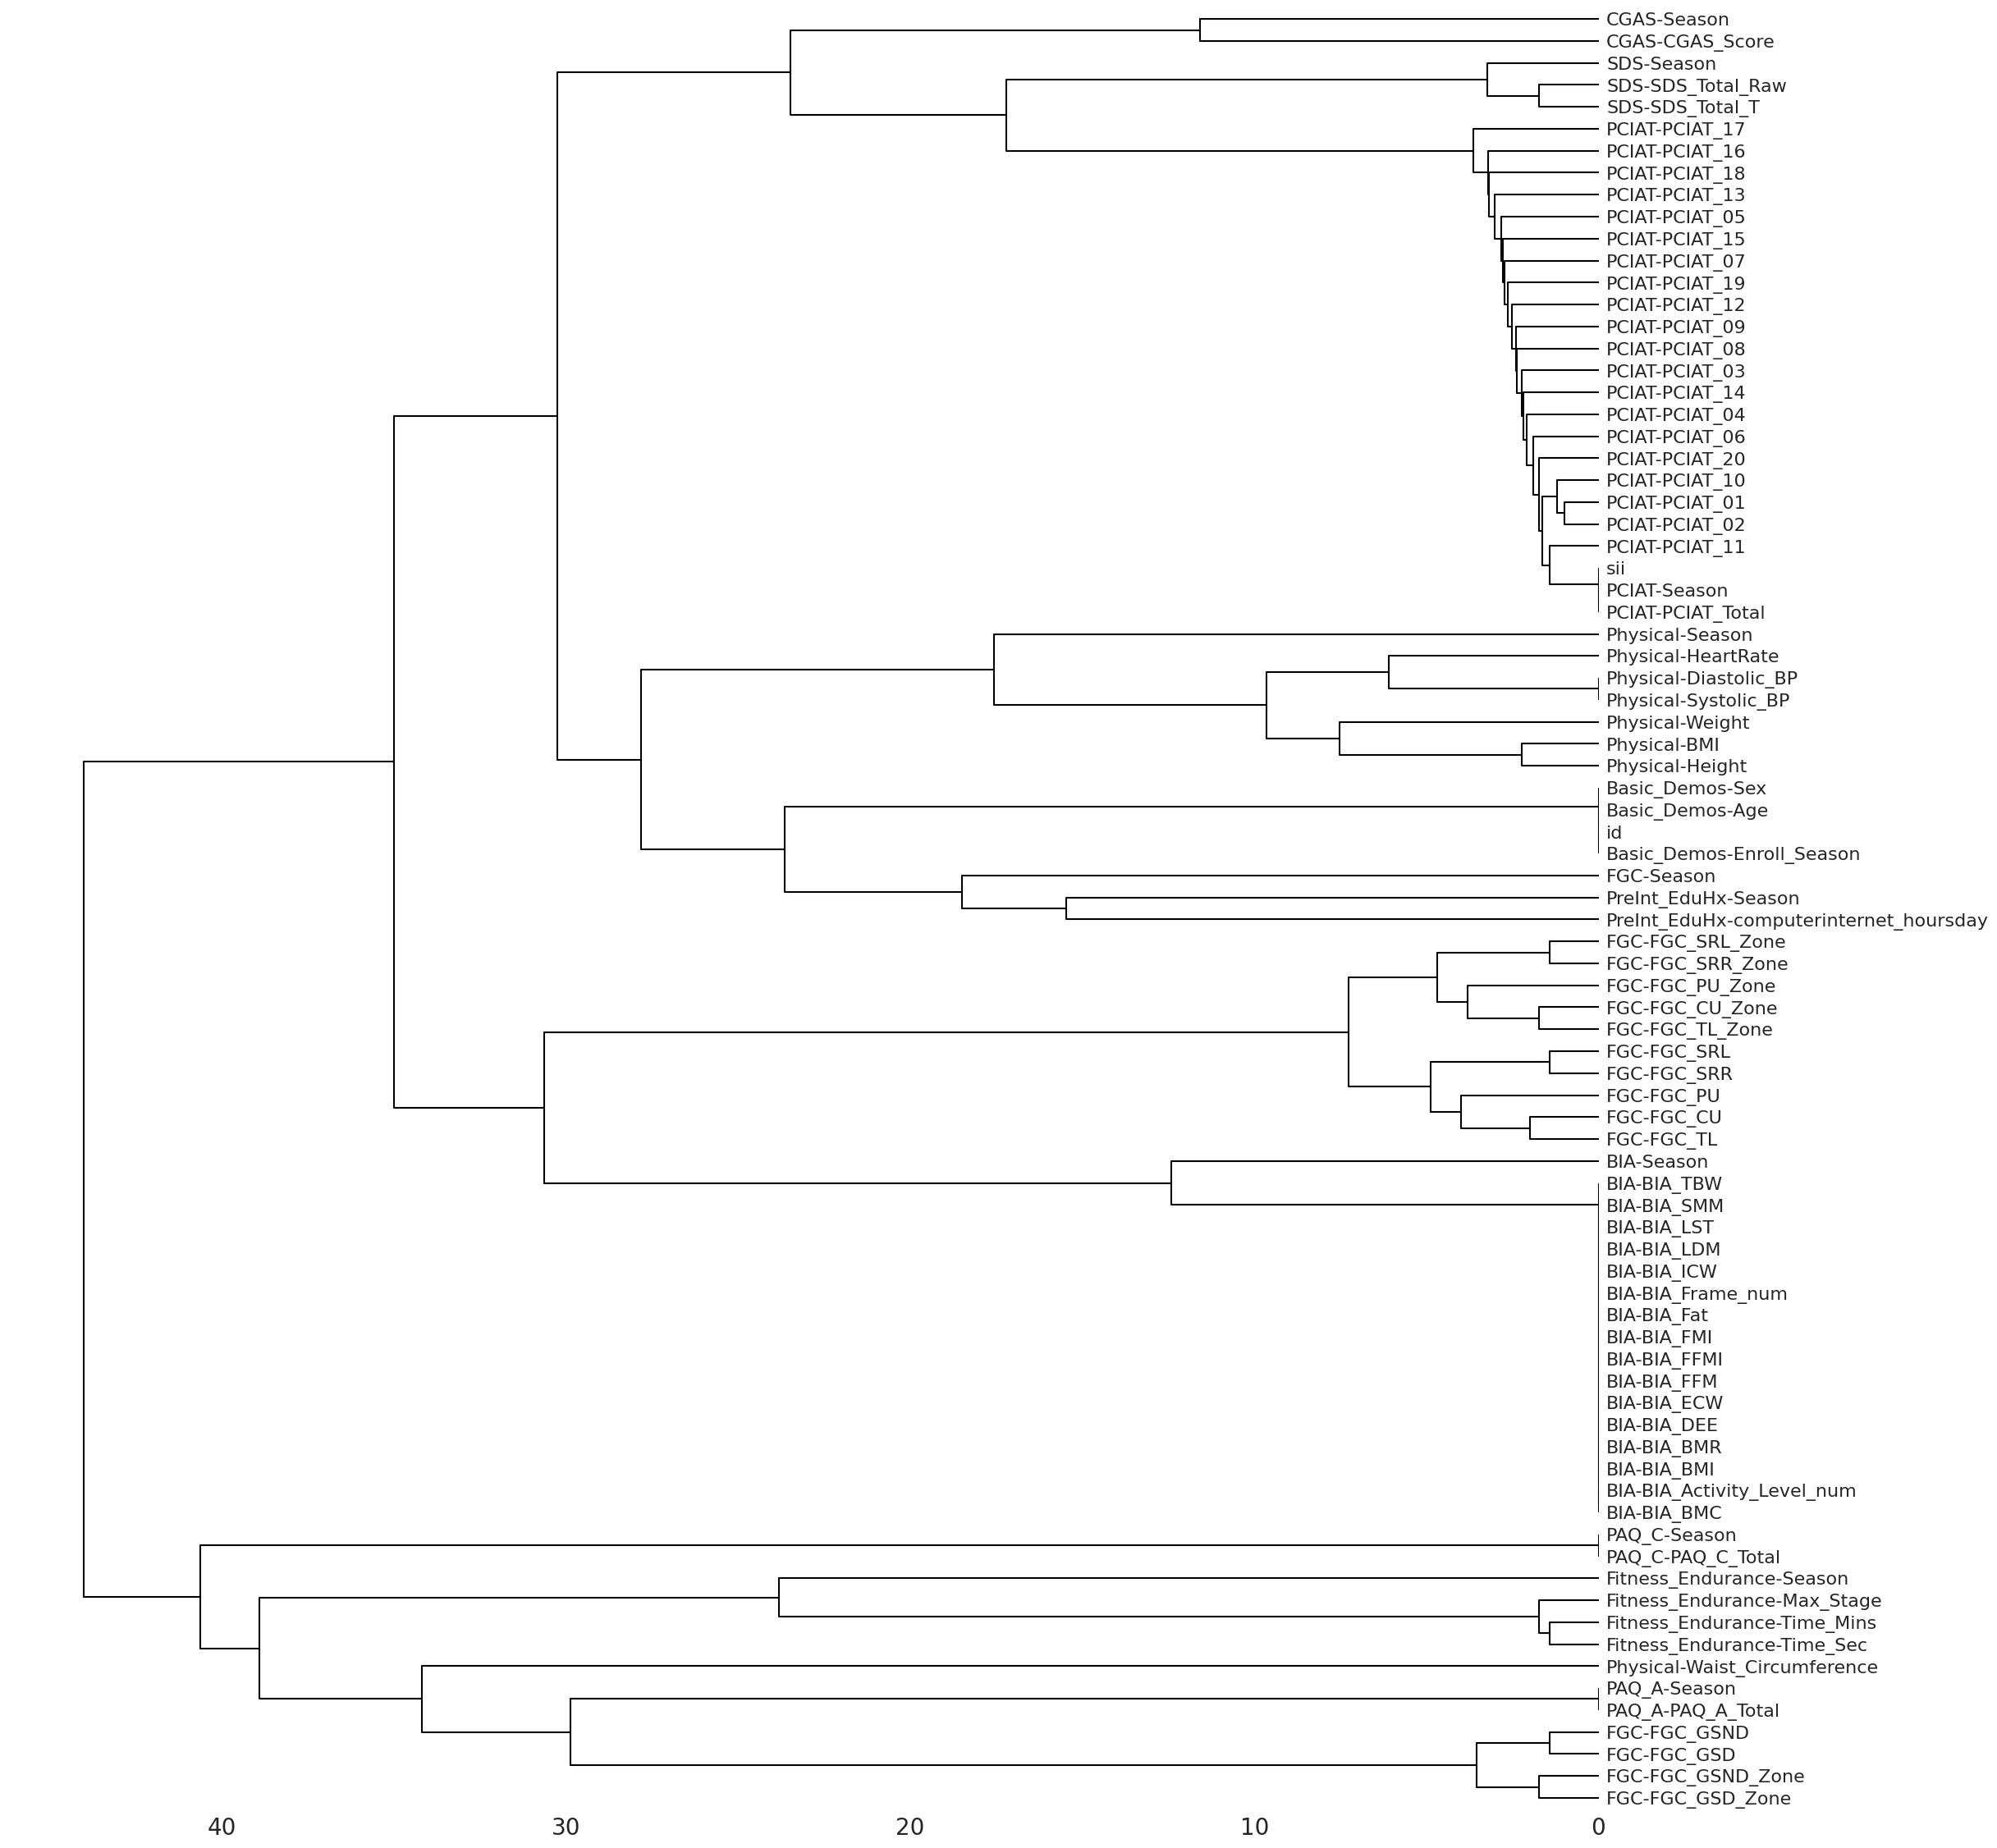

In [37]:
msno.dendrogram(df_train)

<div class="alert alert-block alert-info">
<b></b> We will review the columns available in the test dataframe to ensure predictions can be made without relying on variables that are missing.</div>



In [13]:
columns_useful_to_predict = [col for col in list(df_train.columns) if col in list(df_test.columns)]

print(f'The variables available for prediction are: \n {columns_useful_to_predict}, being in total {len(columns_useful_to_predict)}.')

The variables available for prediction are: 
 ['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-Season', 'PA

### **SII Analysis**

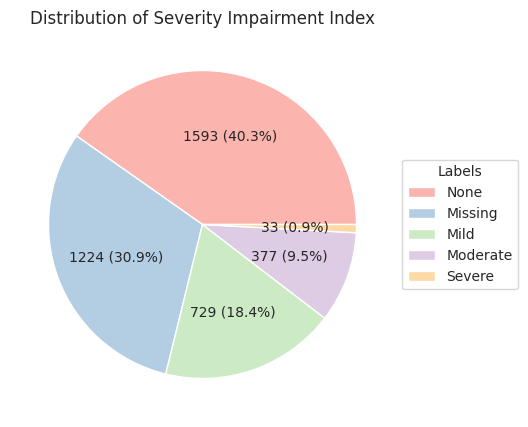

In [21]:
labels_map = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe', -1: 'Missing'}
label_counts = df_train['sii'].map(lambda x: labels_map.get(x, 'Missing')).value_counts()

def func(pct, allvals):
    absolute = int(pct / 100. * sum(allvals))
    return f"{absolute} ({pct:.1f}%)"

plt.figure(figsize=(10, 5))
wedges, texts, autotexts = plt.pie(
    label_counts, 
    autopct=lambda pct: func(pct, label_counts), 
    labels=[None] * len(label_counts), 
    colors=plt.cm.Pastel1.colors)

plt.legend(
    wedges, 
    label_counts.index, 
    title="Labels", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)
plt.title("Distribution of Severity Impairment Index")
display()

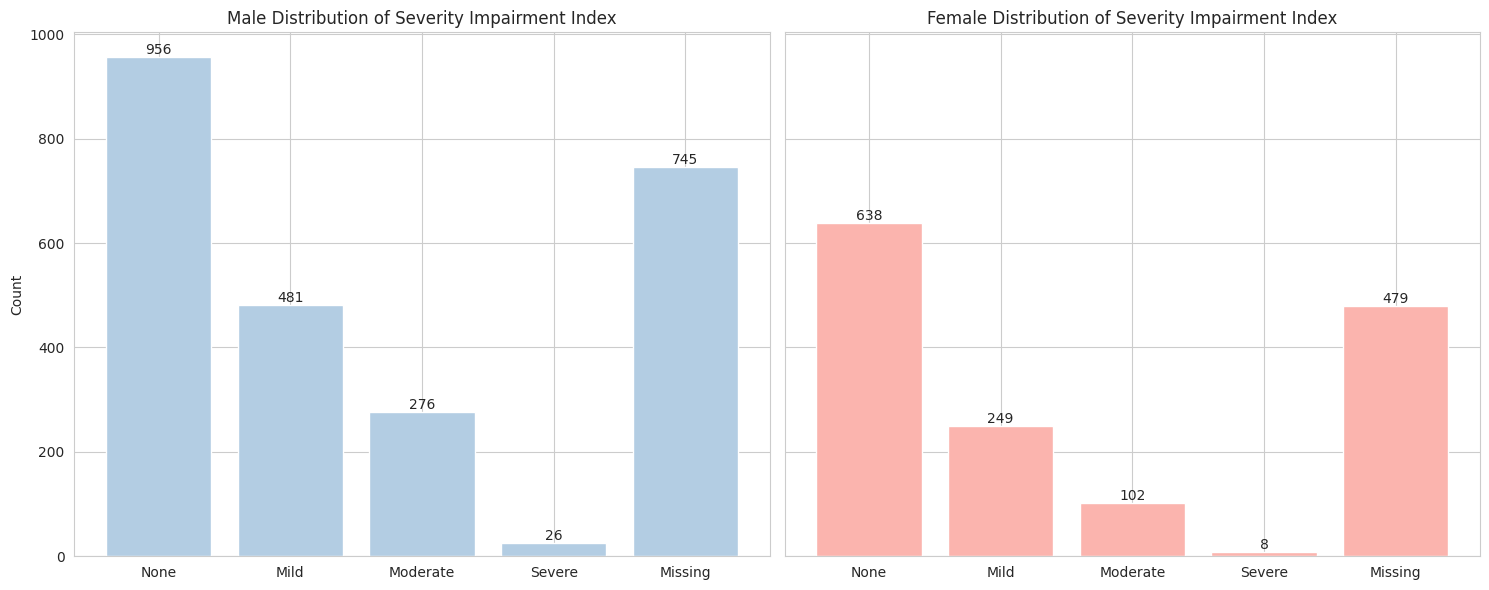

In [33]:
male_label_counts = df_train[df_train['Basic_Demos-Sex'] == 0]['sii'].map(lambda x: labels_map.get(x, 'Missing')).value_counts()
female_label_counts = df_train[df_train['Basic_Demos-Sex'] == 1]['sii'].map(lambda x: labels_map.get(x, 'Missing')).value_counts()

categories = list(labels_map.values())
male_label_counts = male_label_counts.reindex(categories, fill_value=0)
female_label_counts = female_label_counts.reindex(categories, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

bars_male = axes[0].bar(
    male_label_counts.index, 
    male_label_counts.values, 
    color=plt.cm.Pastel1.colors[1])

axes[0].set_title('Male Distribution of Severity Impairment Index')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x')

for bar in bars_male:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, 
        height, 
        str(height), 
        ha='center', 
        va='bottom')

bars_female = axes[1].bar(
    female_label_counts.index, 
    female_label_counts.values, 
    color=plt.cm.Pastel1.colors[0])

axes[1].set_title('Female Distribution of Severity Impairment Index')
axes[1].tick_params(axis='x')

for bar in bars_female:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, 
        height, 
        str(height), 
        ha='center', 
        va='bottom')

plt.tight_layout()
display()